In [65]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import indicators
from src.main import get_data

In [66]:
data = get_data(["ENR"], "2023-11-01", "2026-05-05")

closing = data["Close"].ENR



[*********************100%***********************]  1 of 1 completed


In [67]:
ma_50 = indicators.calc_ma(data["Close"], 50, "sma")
ma_200 = indicators.calc_ma(data["Close"], 200, "sma")

ma_9 = indicators.calc_ma(data["Close"], 9, "ema")
ma_21 = indicators.calc_ma(data["Close"], 21, "ema")

stock_rsi = indicators.calc_rsi(data["Close"])

In [68]:
print(
f"End: {closing.iat[-1]:.2f}\n\
Start: {closing.iat[0]:.2f}\n\
Difference: {closing.iat[-1] - closing.iat[0]:.2f}\n\
Log return: {np.log(closing.iat[-1] / closing.iat[0])*100:.2f}%"
)

End: 19.34
Start: 28.21
Difference: -8.87
Log return: -37.76%


In [69]:
log_rt = indicators.calc_log_rt(closing)
vol = indicators.calc_r_vol(log_rt, 30)

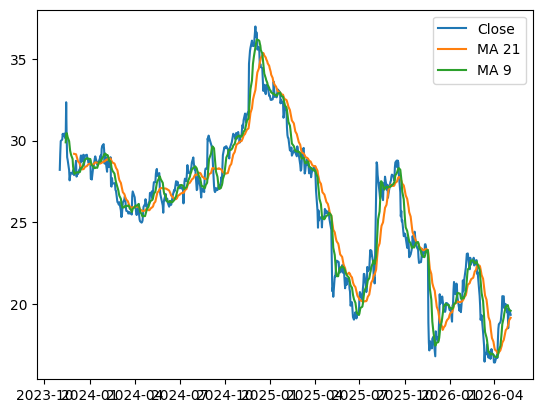

In [70]:
# plt.plot(rsi, label="RSI")
plt.ion()
plt.plot(data["Close"], label="Close")
# plt.plot(ma_50, label="MA 50")
# plt.plot(ma_200, label="MA 200")

plt.plot(ma_21, label="MA 21")
plt.plot(ma_9, label="MA 9")

# plt.plot(100 * vol, label="Volatility (scaled)")

plt.legend()
plt.show()

In [71]:
highs = data["High"]
lows = data["Low"]

up_move = highs - highs.shift(1)
down_move = lows.shift(1) - lows

dm_plus = ((up_move > down_move) & (up_move > 0)) * up_move
dm_minus = ((down_move > up_move) & (down_move > 0)) * down_move

dm_plus = dm_plus.squeeze()
dm_minus = dm_minus.squeeze()

In [85]:
first = highs - lows
second = (highs - closing.shift(1)).abs()
third = (lows - closing.shift(1)).abs()

tr = pd.concat([
    first,
    second,
    third
], axis=1).max(axis=1)

atr = tr.ewm(alpha=1/14, adjust=False).mean()
atr

Date
2023-11-01    0.607273
2023-11-02    0.617317
2023-11-03    0.630803
2023-11-06    0.626371
2023-11-07    0.614323
                ...   
2026-04-28    0.694714
2026-04-29    0.752948
2026-04-30    0.761309
2026-05-01    0.758358
2026-05-04    0.762404
Length: 627, dtype: float64

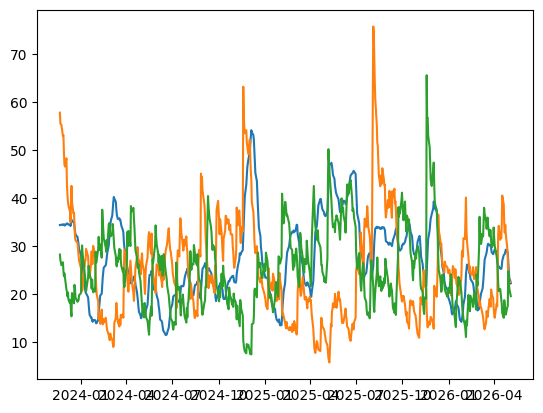

In [88]:
dm_plus_smooth = dm_plus.ewm(alpha=1/14, adjust=False).mean()
dm_minus_smooth = dm_minus.ewm(alpha=1/14, adjust=False).mean()

dm_plus_smooth[:14] = np.nan
dm_minus_smooth[:14] = np.nan

di_plus = 100 * dm_plus_smooth / atr
di_minus = 100 * dm_minus_smooth / atr

dx = (di_plus - di_minus).abs() / (di_plus + di_minus).abs() * 100.0
dx[:14] = np.nan
adx = dx.ewm(alpha=1/14, adjust=False).mean()


plt.plot(adx)
plt.plot(di_plus)
plt.plot(di_minus)